<a href="https://colab.research.google.com/github/devpatel0005/TechMicra-AIML-Summer-Internship/blob/main/Stock_Sentiment_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

### Data Analysis and Basic EDA

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/devpatel0005/TechMicra-AIML-Summer-Internship/refs/heads/main/Datasets/Sentiment_Stock_data.csv')
df.sample(5)

,Unnamed: 0,Sentiment,Sentence
106393,108936,0,"On the Run from the Islamic State, Assyrians A..."
724,724,1,HELSINKI AFX - Outokumpu said its technology u...
60642,63156,0,b'U.S. Missile Kills 10 in Pakistan. Has anyo...
74506,77033,1,Jordanians have staged growing protests in the...
48059,49944,0,Owner of Anglian Water backs a £2.2bn takeover...


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Sentiment,0
Sentence,1


In [ ]:
df = df.dropna()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108750 entries, 0 to 108750
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  108750 non-null  int64 
 1   Sentiment   108750 non-null  int64 
 2   Sentence    108750 non-null  object
dtypes: int64(2), object(1)
memory usage: 3.3+ MB


In [ ]:
print(f"Shape of the DataFrame: {df.shape}")

Shape of the DataFrame: (108750, 4)


In [ ]:
print("Sentiment Distribution:")
display(df['Sentiment'].value_counts())

Sentiment Distribution:


,count
Sentiment,
1,55724
0,53026


The `Unnamed: 0` column seems to be an old index. Let's drop it as it is not useful for sentiment analysis.

In [ ]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
else:
    print("'Unnamed: 0' column not found.")

df.info()

'Unnamed: 0' column not found.
<class 'pandas.core.frame.DataFrame'>
Index: 108750 entries, 0 to 108750
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Sentiment        108750 non-null  int64 
 1   Sentence         108750 non-null  object
 2   Sentence_Length  108750 non-null  int64 
 3   Word_Count       108750 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.1+ MB


Let's visualize the sentiment distribution.

/tmp/ipykernel_444/2832920033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


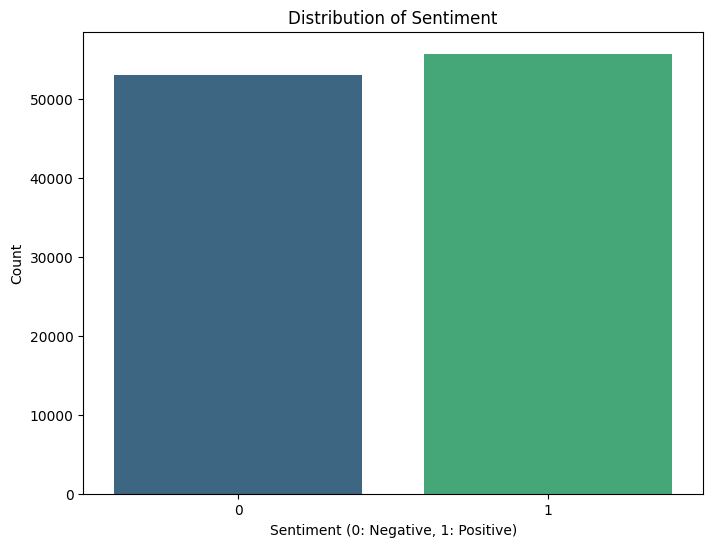

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

### Text Data Analysis (Sentence Length and Word Count)

In [ ]:
# Calculate sentence length
df['Sentence_Length'] = df['Sentence'].apply(len)

# Calculate word count
df['Word_Count'] = df['Sentence'].apply(lambda x: len(str(x).split()))

# Display descriptive statistics for these new columns
print("Descriptive statistics for Sentence Length:")
display(df['Sentence_Length'].describe())

print("\nDescriptive statistics for Word Count:")
display(df['Word_Count'].describe())

Descriptive statistics for Sentence Length:


,Sentence_Length
count,108750.000000
mean,76.941067
std,62.399292
min,1.000000
25%,36.000000
50%,53.000000
75%,94.000000
max,315.000000



Descriptive statistics for Word Count:


,Word_Count
count,108750.000000
mean,12.607807
std,10.337058
min,1.000000
25%,6.000000
50%,9.000000
75%,15.000000
max,81.000000


Let's visualize the distribution of sentence lengths and word counts.

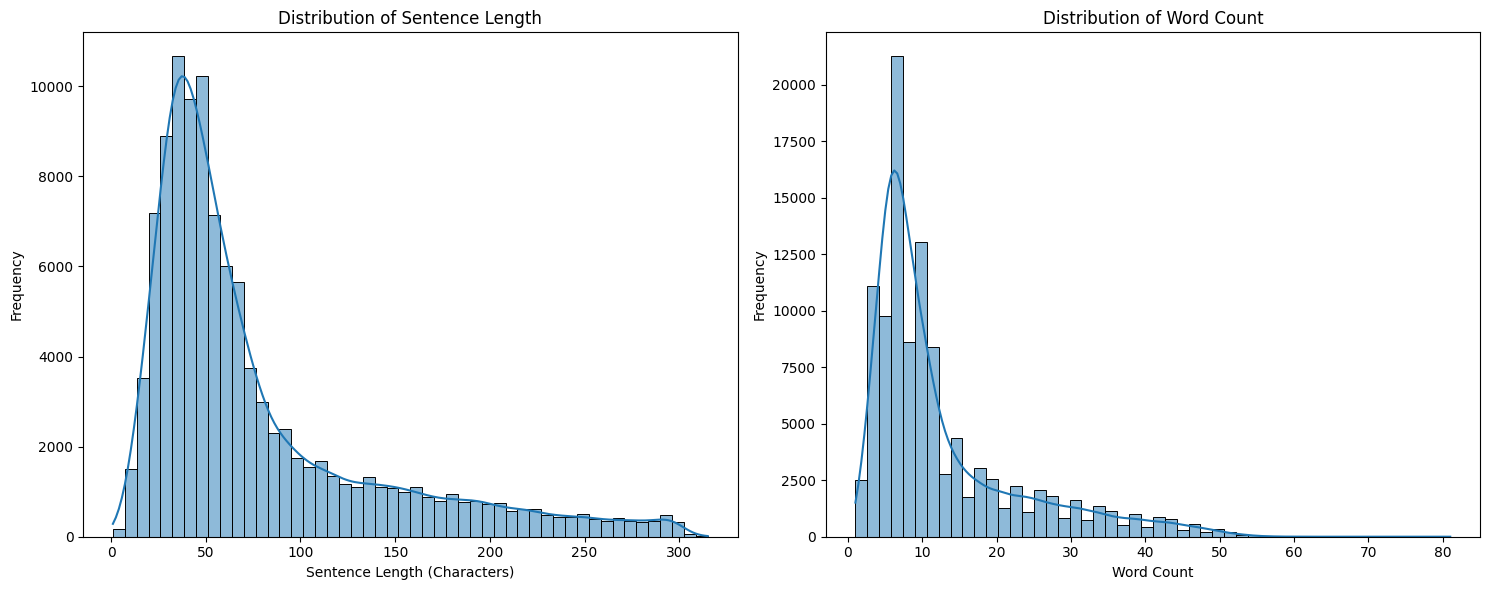

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['Sentence_Length'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sentence Length')
axes[0].set_xlabel('Sentence Length (Characters)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['Word_Count'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### EDA Summary

So far, we have:
- Loaded the dataset and inspected its initial rows.
- Handled missing values by dropping the row with a null 'Sentence'.
- Removed duplicate entries.
- Identified and removed an irrelevant 'Unnamed: 0' column.
- Examined the overall shape of the dataset.
- Analyzed and visualized the distribution of sentiment (positive vs. negative).
- Explored the characteristics of the text data by calculating and visualizing the distribution of sentence lengths and word counts.

This initial EDA provides a good foundation for understanding the dataset and prepares us for subsequent text preprocessing and model building steps.

### Feature Engineering and Preprocessing

To prepare the text data for machine learning models, we need to convert it into a numerical format. TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique that reflects how important a word is to a document in a collection or corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf_vectorizer.fit_transform(df['Sentence'])

print(f"Shape of TF-IDF features: {X_tfidf.shape}")

Shape of TF-IDF features: (108750, 5000)


Now, let's combine the TF-IDF features with the numerical features ('Sentence_Length', 'Word_Count') we engineered earlier. This creates a comprehensive feature set for our model.

In [ ]:
from scipy.sparse import hstack

numerical_features = df[['Sentence_Length', 'Word_Count']].values

X = hstack([X_tfidf, numerical_features])

y = df['Sentiment']

print(f"Shape of combined features (X): {X.shape}")
print(f"Shape of target variable (y): {y.shape}")

Shape of combined features (X): (108750, 5002)
Shape of target variable (y): (108750,)


Finally, we will split the data into training and testing sets. This is crucial for evaluating the model's performance on unseen data. A common split is 80% for training and 20% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (87000, 5002)
Shape of X_test: (21750, 5002)
Shape of y_train: (87000,)
Shape of y_test: (21750,)


### Model Training and Hyperparameter Tuning (Random Forest with RandomizedSearchCV)

We will use `RandomizedSearchCV` to systematically work through multiple combinations of parameter tunes, cross-validating as it goes to determine which tune works best. This helps in finding the optimal hyperparameters for our Random Forest model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

param_grid = {
    'n_estimators': [10,30,50,100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                           n_iter=3, cv=2, n_jobs=-1, verbose=2, scoring='f1', random_state=42)

print("Starting RandomizedSearchCV with reduced iterations for speed...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV complete.")

best_params = random_search.best_params_
best_rf_model = random_search.best_estimator_

print(f"\nBest Parameters found by RandomizedSearchCV: {best_params}")

Starting RandomizedSearchCV with reduced iterations for speed...
Fitting 2 folds for each of 3 candidates, totalling 6 fits
RandomizedSearchCV complete.

Best Parameters found by RandomizedSearchCV: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


Now, let's evaluate the performance of the best Random Forest model found by RandomizedSearchCV on both the training and test sets.


--- Evaluation on Training Set ---
Training Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.12      0.21     42421
           1       0.53      0.96      0.69     44579

    accuracy                           0.55     87000
   macro avg       0.64      0.54      0.45     87000
weighted avg       0.63      0.55      0.45     87000



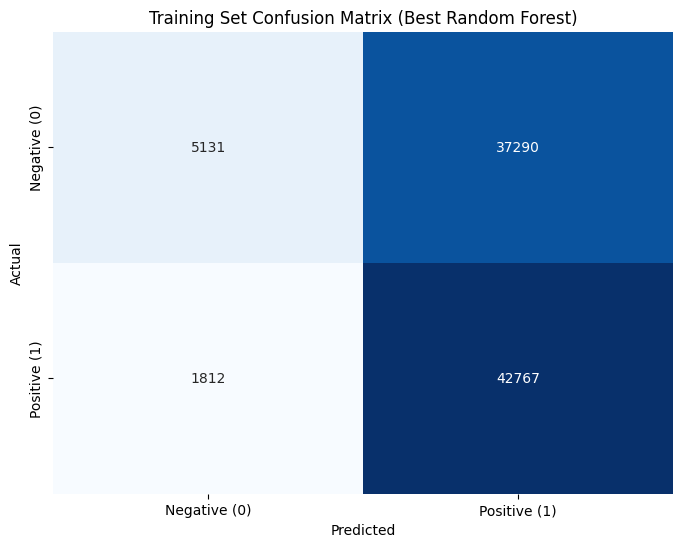


--- Evaluation on Test Set ---
Test Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.11      0.19     10605
           1       0.53      0.94      0.68     11145

    accuracy                           0.54     21750
   macro avg       0.59      0.53      0.43     21750
weighted avg       0.59      0.54      0.44     21750



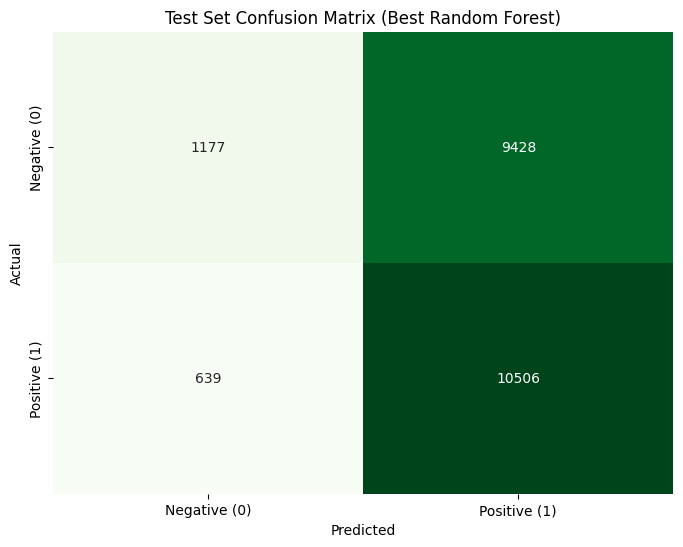

In [ ]:
print("\n--- Evaluation on Training Set ---")
y_train_pred = best_rf_model.predict(X_train)

print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))

cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Training Set Confusion Matrix (Best Random Forest)')
plt.show()

print("\n--- Evaluation on Test Set ---")
y_test_pred = best_rf_model.predict(X_test)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Set Confusion Matrix (Best Random Forest)')
plt.show()

### Neural Network Approach (Bi-LSTM)

First, we need to import the necessary libraries for building our neural network and preprocessing the text data. We'll use TensorFlow and Keras for this.

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Next, we will tokenize the text data, converting words into numerical sequences. We'll also define a maximum sequence length and pad our sequences so they all have the same length, which is required for neural network input.

In [5]:
max_words = 10000  # Consider the top 10,000 words
max_len = 100    # Pad sequences to a maximum length of 100 words

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
# Convert 'Sentence' column to string type to prevent AttributeError if there are non-string entries
tokenizer.fit_on_texts(df['Sentence'].astype(str))

word_index = tokenizer.word_index
print(f"Found {len(word_index)} unique tokens.")

sentences_seq = tokenizer.texts_to_sequences(df['Sentence'].astype(str))
sentences_padded = pad_sequences(sentences_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Shape of padded sequences: {sentences_padded.shape}")

Found 65753 unique tokens.
Shape of padded sequences: (108751, 100)


Now, we need to split our processed data (padded sequences and sentiments) into training and testing sets, similar to what we did for the Random Forest model.

In [6]:
from sklearn.model_selection import train_test_split

X_nn = sentences_padded
y_nn = df['Sentiment']

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.2, random_state=42, stratify=y_nn)

print(f"Shape of X_train_nn: {X_train_nn.shape}")
print(f"Shape of X_test_nn: {X_test_nn.shape}")
print(f"Shape of y_train_nn: {y_train_nn.shape}")
print(f"Shape of y_test_nn: {y_test_nn.shape}")

Shape of X_train_nn: (87000, 100)
Shape of X_test_nn: (21751, 100)
Shape of y_train_nn: (87000,)
Shape of y_test_nn: (21751,)


Now, let's build the Bi-LSTM model. We'll use an Embedding layer to convert word indices into dense vectors, followed by a Bidirectional LSTM layer to capture sequential information in both directions. Finally, a Dense layer with a sigmoid activation will output the sentiment probability.

In [7]:
embedding_dim = 128 # Dimension of the word embeddings

model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)), # Using return_sequences=True for stacking LSTMs
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,260,293 (16.25 MB)

 Trainable params: 1,420,097 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,840,196 (10.83 MB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Now, we'll train the Bi-LSTM model on our training data. We'll use a validation split to monitor performance on unseen data during training.

Epoch 1/5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 78s 28ms/step - accuracy: 0.5306 - loss: 0.6866 - val_accuracy: 0.5380 - val_loss: 0.6796
Epoch 2/5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 60s 22ms/step - accuracy: 0.5806 - loss: 0.6607 - val_accuracy: 0.5301 - val_loss: 0.6834
Epoch 3/5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - accuracy: 0.6339 - loss: 0.6162 - val_accuracy: 0.5354 - val_loss: 0.7050
Epoch 4/5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 0.6757 - loss: 0.5688 - val_accuracy: 0.5298 - val_loss: 0.7709
Epoch 5/5
2447/2447 ━━━━━━━━━━━━━━━━━━━━ 50s 20ms/step - accuracy: 0.7138 - loss: 0.5171 - val_accuracy: 0.5317 - val_loss: 0.8640


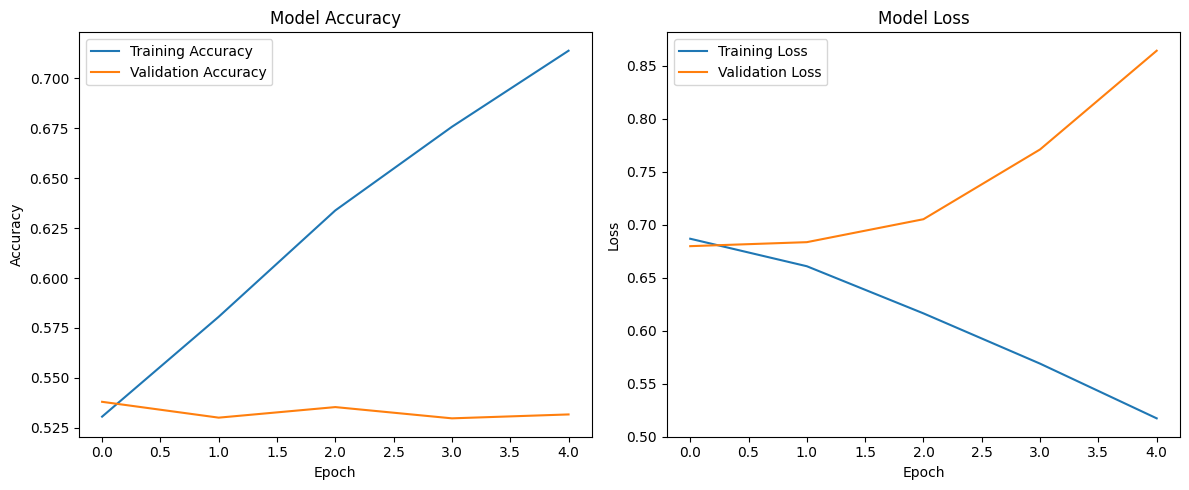

In [8]:
epochs = 5
batch_size = 32

history = model.fit(X_train_nn, y_train_nn, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Finally, let's evaluate the trained Bi-LSTM model on the test set and visualize its performance using a classification report and confusion matrix.


--- Evaluation on Test Set (Bi-LSTM) ---
680/680 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
Test Classification Report (Bi-LSTM):
              precision    recall  f1-score   support

           0       0.52      0.51      0.51     10606
           1       0.54      0.56      0.55     11145

    accuracy                           0.53     21751
   macro avg       0.53      0.53      0.53     21751
weighted avg       0.53      0.53      0.53     21751



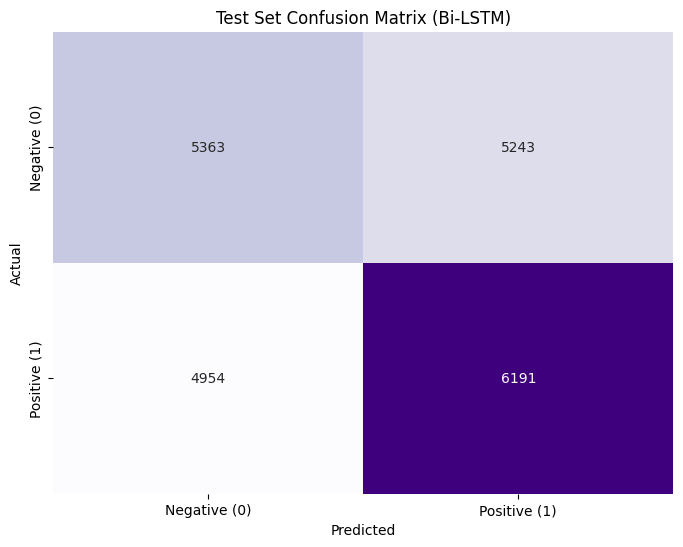

In [9]:
print("\n--- Evaluation on Test Set (Bi-LSTM) ---")
y_pred_nn_prob = model.predict(X_test_nn)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int) # Convert probabilities to binary predictions

print("Test Classification Report (Bi-LSTM):")
print(classification_report(y_test_nn, y_pred_nn))

cm_nn_test = confusion_matrix(y_test_nn, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn_test, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Set Confusion Matrix (Bi-LSTM)')
plt.show()